In [8]:
import sys
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import gc
import numpy as np
import tensorflow as tf

# 1. Añadimos la ruta ABSOLUTA de tu carpeta Polilla_LLama al path de Python
ruta_modulo = os.path.abspath('.')
if ruta_modulo not in sys.path:
    sys.path.append(ruta_modulo)

# 2. Importamos el optimizador
from mfo_optimizado import MothFlameOptimizer

print("Optimizador importado correctamente:", MothFlameOptimizer)

import pandas as pd

# 3. Cargamos el dataset con la ruta absoluta que ya tenías
ruta_csv = os.path.join('..', '..', 'Dataset', 'default of credit card clients.csv')
df = pd.read_csv(ruta_csv, sep=',', skiprows=1)

display(df.head())

Optimizador importado correctamente: <class 'mfo_optimizado.MothFlameOptimizer'>


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Limpieza de columnas
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# 2. Separar características (X) y objetivo (y)
X = df.drop('default', axis=1)
y = df['default']

# 3. Dividir en Entrenamiento y Prueba (80/20) garantizando proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos listos y escalados.")
print(f"Tamaño de entrenamiento: {X_train_scaled.shape}")

✅ Datos listos y escalados.
Tamaño de entrenamiento: (24000, 23)


In [10]:
def objetivo_modelo(params):
    import numpy as np 
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    import gc
    
    lr, dropout, n1, n2 = params
    
    model = Sequential([
        Dense(int(n1), activation='relu', input_dim=X_train_scaled.shape[1]),
        BatchNormalization(),
        Dropout(np.clip(dropout, 0.1, 0.5)),
        Dense(int(n2), activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=max(lr, 1e-5)), 
                  loss='binary_crossentropy', 
                  metrics=[tf.keras.metrics.AUC(name='auc')])
    
    history = model.fit(X_train_scaled, y_train, validation_split=0.2, 
                        epochs=15, batch_size=256, verbose=0,
                        callbacks=[EarlyStopping(monitor='val_auc', patience=3)])
    
    mejor_auc = max(history.history['val_auc'])
    
    tf.keras.backend.clear_session()
    gc.collect()
    
    return 1.0 - mejor_auc


# --- EJECUCIÓN DEL OPTIMIZADOR ---
# Instanciamos el optimizador con 10 polillas y 10 iteraciones para probar
mfo = MothFlameOptimizer(objective_function=objetivo_modelo, dim=4, n_moths=10, max_iter=10)

# Rangos: lr [0.0001, 0.01], dropout [0.1, 0.5], n1 [16, 128], n2 [8, 64]
limites = [(0.0001, 0.01), (0.1, 0.5), (16, 128), (8, 64)]

print("Iniciando la búsqueda de hiperparámetros...")
best_params, best_score = mfo.optimize(limites)

print("="*50)
print(f"Los mejores hiperparámetros encontrados son: {best_params}")
print(f"AUC máximo alcanzado: {1 - best_score:.4f}")

# Guardamos el estado para el modelo híbrido posterior
mfo.save_state('pesos_mfo.pkl')
print("Pesos guardados en 'pesos_mfo.pkl'")

Iniciando la búsqueda de hiperparámetros...


c:\Users\denni\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Los mejores hiperparámetros encontrados son: [3.38648456e-03 2.63595888e-01 1.17859019e+02 6.15523000e+01]
AUC máximo alcanzado: 0.7805
Pesos guardados en 'pesos_mfo.pkl'


Ejecutar la Metaheurística y Guardar los Pesos

In [11]:
# --- PASO 1: EJECUTAR EL OPTIMIZADOR MFO ---
print("Iniciando la búsqueda de hiperparámetros con Polilla y Llama (MFO)...")

# Instanciamos el optimizador con 10 polillas y 10 iteraciones (puedes subirlo a 20 luego)
mfo = MothFlameOptimizer(objective_function=objetivo_modelo, dim=4, n_moths=10, max_iter=10)

# Rangos: lr [0.0001, 0.01], dropout [0.1, 0.5], n1 [16, 128], n2 [8, 64]
limites = [(0.0001, 0.01), (0.1, 0.5), (16, 128), (8, 64)]

best_params, best_score = mfo.optimize(limites)

print("\n" + "="*60)
print(f"✅ Mejores hiperparámetros encontrados: LR={best_params[0]:.5f}, Dropout={best_params[1]:.2f}, N1={int(best_params[2])}, N2={int(best_params[3])}")
print(f"✅ AUC máximo alcanzado en validación: {1 - best_score:.4f}")
print("="*60)

# Guardamos el estado para no tener que volver a buscar los parámetros después
mfo.save_state('pesos_mfo.pkl')
print("💾 Pesos guardados exitosamente en 'pesos_mfo.pkl'")

Iniciando la búsqueda de hiperparámetros con Polilla y Llama (MFO)...

✅ Mejores hiperparámetros encontrados: LR=0.00937, Dropout=0.32, N1=75, N2=61
✅ AUC máximo alcanzado en validación: 0.7814
💾 Pesos guardados exitosamente en 'pesos_mfo.pkl'


Entrenar el Modelo Final

In [12]:
# --- PASO 2: ENTRENAMIENTO DEL MODELO FINAL ---
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr_opt, drop_opt, n1_opt, n2_opt = best_params

print("\n🚀 Entrenando modelo final con los hiperparámetros óptimos...")
modelo_final = Sequential([
    Dense(int(n1_opt), activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(np.clip(drop_opt, 0.1, 0.5)),
    Dense(int(n2_opt), activation='relu'),
    Dense(1, activation='sigmoid')
])

modelo_final.compile(optimizer=Adam(learning_rate=max(lr_opt, 1e-5)), 
              loss='binary_crossentropy', 
              metrics=[tf.keras.metrics.AUC(name='auc')])

# Entrenamos por más épocas ya que es el modelo definitivo
history_final = modelo_final.fit(
    X_train_scaled, y_train, 
    validation_split=0.2, 
    epochs=30, 
    batch_size=256, 
    verbose=1,
    callbacks=[EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True)]
)

# Predicciones
y_pred_prob = modelo_final.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n📊 REPORTE DE CLASIFICACIÓN (MFO - MLP)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Cumple (0)', 'Incumple (1)']))
print(f"ROC-AUC Final: {roc_auc_score(y_test, y_pred_prob):.4f}")


🚀 Entrenando modelo final con los hiperparámetros óptimos...
Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7302 - loss: 0.4647 - val_auc: 0.7549 - val_loss: 0.5510
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7592 - loss: 0.4408 - val_auc: 0.7641 - val_loss: 0.4679
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7671 - loss: 0.4363 - val_auc: 0.7654 - val_loss: 0.4576
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7698 - loss: 0.4340 - val_auc: 0.7640 - val_loss: 0.4532
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7753 - loss: 0.4322 - val_auc: 0.7723 - val_loss: 0.4479
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7761 - loss: 0.4307 - val_auc: 0.7737 - val_loss: 0.4530
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7754 - loss: 0.4305 - val_auc: 0.7743 - val_loss: 0.4451
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7746 - loss: 0.4307 - val_auc: 0.7779 - val_loss: 0.4429
Epoch 9/30

Visualizacion 

In [13]:
# --- PASO 3: GRÁFICO 3D INTERACTIVO CON PLOTLY ---
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("\nGenerando entorno 3D interactivo...")

# 1. Aplicar PCA para reducir las 23 características a 2 dimensiones visuales
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# 2. Construir el gráfico 3D
fig = go.Figure(data=[go.Scatter3d(
    x=X_test_pca[:, 0], # Componente Principal 1
    y=X_test_pca[:, 1], # Componente Principal 2
    z=y_pred_prob.flatten(), # Probabilidad predicha por tu modelo
    mode='markers',
    marker=dict(
        size=4,
        color=y_test, # Coloreamos por si realmente incumplió (Rojo) o no (Azul)
        colorscale='RdBu_r', 
        opacity=0.7,
        colorbar=dict(title='Real (1=Incumple, 0=Cumple)', tickvals=[0, 1])
    ),
    text=[f"Probabilidad: {p[0]*100:.1f}%<br>Real: {r}" for p, r in zip(y_pred_prob, y_test)],
    hoverinfo='text'
)])

# 3. Diseño profesional
fig.update_layout(
    title='Superficie de Decisión 3D: Probabilidad de Impago (MFO-MLP)',
    scene=dict(
        xaxis_title='Perfil Financiero (PCA 1)',
        yaxis_title='Perfil Financiero (PCA 2)',
        zaxis_title='Probabilidad de Impago (Red Neuronal)',
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.5))
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()


Generando entorno 3D interactivo...


In [14]:
# --- GRÁFICO PERRÓN 1: CURVAS ROC Y PR INTERACTIVAS ---
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Cálculos matemáticos de las curvas
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc_val = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
pr_auc_val = auc(recall_vals, precision_vals)

# Crear subplots con estilo
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=(f'Curva ROC (AUC = {roc_auc_val:.3f})', 
                                    f'Precision-Recall (AUC = {pr_auc_val:.3f})'))

# Añadir Curva ROC (Izquierda)
fig.add_trace(go.Scatter(x=fpr, y=tpr, fill='tozeroy', 
                         marker_color='springgreen', name='ROC MFO-MLP',
                         line=dict(width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', 
                         line=dict(dash='dash', color='gray'), name='Modelo Aleatorio'), row=1, col=1)

# Añadir Curva Precision-Recall (Derecha)
fig.add_trace(go.Scatter(x=recall_vals, y=precision_vals, fill='tozeroy', 
                         marker_color='magenta', name='PR MFO-MLP',
                         line=dict(width=3)), row=1, col=2)

# Diseño y Tema Oscuro
fig.update_layout(
    title_text='Evaluación de Capacidad Predictiva (Red Neuronal Optimizada por Polilla y Llama)',
    template='plotly_dark',
    height=500,
    showlegend=False
)

fig.update_xaxes(title_text="Tasa de Falsos Positivos", row=1, col=1)
fig.update_yaxes(title_text="Sensibilidad (Recall)", row=1, col=1)
fig.update_xaxes(title_text="Sensibilidad (Recall)", row=1, col=2)
fig.update_yaxes(title_text="Precisión", row=1, col=2)

fig.show()

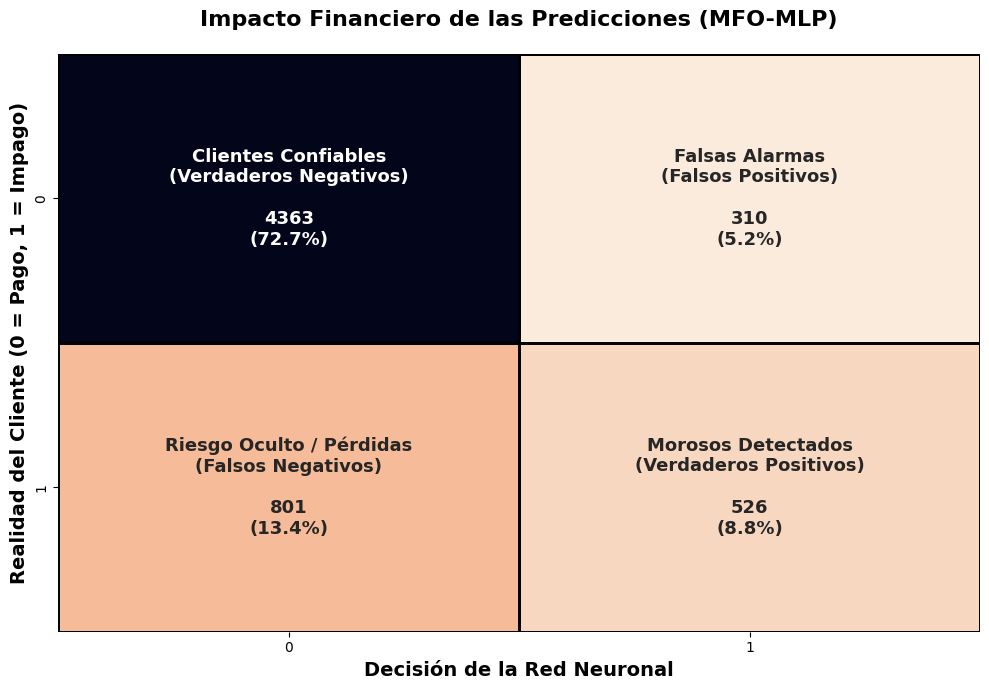

In [15]:
# --- GRÁFICO PERRÓN 2: MATRIZ DE CONFUSIÓN FINANCIERA ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# Crear etiquetas explicativas con el contexto bancario
nombres_grupos = ['Clientes Confiables\n(Verdaderos Negativos)', 'Falsas Alarmas\n(Falsos Positivos)',
                  'Riesgo Oculto / Pérdidas\n(Falsos Negativos)', 'Morosos Detectados\n(Verdaderos Positivos)']

conteos_grupos = ["{0:0.0f}".format(value) for value in cm.flatten()]
porcentajes_grupos = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

# Unir toda la información en las etiquetas del gráfico
etiquetas = [f"{v1}\n\n{v2}\n({v3})" for v1, v2, v3 in zip(nombres_grupos, conteos_grupos, porcentajes_grupos)]
etiquetas = np.asarray(etiquetas).reshape(2,2)

# Crear el gráfico con alto contraste
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=etiquetas, fmt='', cmap='rocket_r', cbar=False, 
            annot_kws={"size": 13, "weight": "bold"}, 
            linewidths=2, linecolor='black')

plt.title('Impacto Financiero de las Predicciones (MFO-MLP)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Realidad del Cliente (0 = Pago, 1 = Impago)', fontsize=14, fontweight='bold')
plt.xlabel('Decisión de la Red Neuronal', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# --- GRÁFICO PERRÓN 3: RADAR DE HIPERPARÁMETROS (EL ADN DEL MODELO) ---
import plotly.graph_objects as go

# Limites que le diste al modelo (para escalar los valores de 0 a 1 visualmente)
max_vals = np.array([0.01, 0.5, 128, 64])
min_vals = np.array([0.0001, 0.1, 16, 8])

# Extraemos best_params del optimizador y los normalizamos
params_norm = (np.array(best_params) - min_vals) / (max_vals - min_vals)

categorias = ['Tasa de Aprendizaje (LR)', 'Tasa de Dropout', 'Neuronas Capa 1', 'Neuronas Capa 2']

fig = go.Figure()

# Trazar el polígono
fig.add_trace(go.Scatterpolar(
    r=np.append(params_norm, params_norm[0]), # Cerramos el polígono
    theta=categorias + [categorias[0]],
    fill='toself',
    fillcolor='rgba(0, 255, 255, 0.4)', # Color cian transparente
    line=dict(color='cyan', width=4),
    name='MFO Óptimo',
    hoverinfo='text',
    text=[f"Valor real: {v:.4f}" if i < 2 else f"Valor real: {int(v)}" for i, v in enumerate(np.append(best_params, best_params[0]))]
))

# Diseño sci-fi
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], showticklabels=False, gridcolor='gray'),
        angularaxis=dict(gridcolor='gray', tickfont=dict(size=14, color='white'))
    ),
    title=dict(text="ADN de Hiperparámetros (Configuración MFO)", font=dict(size=20)),
    template="plotly_dark",
    width=700, height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.show()

In [17]:
# --- GRÁFICO PERRÓN 4: LA INTUICIÓN DEL MFO (VUELO EN ESPIRAL) ---
import numpy as np
import plotly.graph_objects as go

print("Generando simulación 3D del vuelo de las polillas hacia la llama...")

fig = go.Figure()

# Configuración de la simulación matemática de la espiral
n_moths = 7            # Número de polillas a simular
b = 1.5                # Constante de la forma de la espiral logarítmica
vueltas = 3            # Número de giros alrededor de la llama

# 1. Dibujar la "Llama" en el centro (El Óptimo Global)
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(
        size=25, 
        color='orange', 
        colorscale='YlOrRd', 
        symbol='circle',
        line=dict(color='yellow', width=4),
        opacity=0.9
    ),
    name='🔥 LLAMA (Mejor Solución)'
))

# 2. Generar y dibujar las "Polillas" y sus trayectorias en espiral
for i in range(n_moths):
    # Punto de inicio aleatorio para cada polilla en el espacio 3D
    r_start = np.random.uniform(5, 10)
    theta_offset = np.random.uniform(0, 2 * np.pi)
    z_start = np.random.uniform(3, 8)
    
    # Vector de tiempo 't' (de 1 a 0 para simular que se acercan al centro)
    t = np.linspace(1, 0, 150)
    
    # Ecuación de la Espiral Logarítmica del algoritmo MFO: r = D * e^(bt) * cos(2*pi*t)
    # Proyectado en 3D para la visualización
    r = r_start * np.exp(b * (t - 1))
    x = r * np.cos(2 * np.pi * t * vueltas + theta_offset)
    y = r * np.sin(2 * np.pi * t * vueltas + theta_offset)
    z = z_start * t  # Descenso en el eje Z hacia la llama
    
    # Dibujar la trayectoria (La estela del vuelo)
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='lines',
        line=dict(
            color='cyan' if i % 2 == 0 else 'magenta', 
            width=4, 
            dash='solid' if i % 2 == 0 else 'dot'
        ),
        name=f'Trayectoria Polilla {i+1}'
    ))
    
    # Dibujar la "Polilla" al inicio de la trayectoria
    fig.add_trace(go.Scatter3d(
        x=[x[0]], y=[y[0]], z=[z[0]],
        mode='markers',
        marker=dict(
            size=6, 
            color='white', 
            symbol='diamond'
        ),
        name=f'🦋 Polilla {i+1} (Solución Inicial)',
        showlegend=False
    ))

# 3. Diseño visual y entorno
fig.update_layout(
    title=dict(
        text="Intuición Matemática de MFO: Convergencia en Espiral Logarítmica", 
        font=dict(size=18, color='white')
    ),
    scene=dict(
        xaxis=dict(title='Espacio de Búsqueda X', showbackground=False, showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(title='Espacio de Búsqueda Y', showbackground=False, showgrid=False, zeroline=False, showticklabels=False),
        zaxis=dict(title='Fitness (Error)', showbackground=False, gridcolor='gray', zeroline=False),
        camera=dict(eye=dict(x=1.2, y=1.2, z=0.8)) # Ángulo de cámara sci-fi
    ),
    template="plotly_dark",
    width=900, 
    height=700,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

fig.show()

Generando simulación 3D del vuelo de las polillas hacia la llama...
